# AIVAT Verification Notebook

**AIVAT** (Adversarial Information Value Decomposition) és una tècnica de reducció de variància proposada a:
> *Brown, N., Bakhtin, A., Lerer, A., & Gong, Q. (2020). Combining Deep Reinforcement Learning and Search for Imperfect-Information Games.*

## Motivació

En jocs d'informació imperfecta com el Truc, la variància de l'avaluació depèn molt de la **sort** (les cartes que et surten). Si vols comparar DQN vs NFSP amb precisió, necessites moltes partides per reduir aquest soroll.

AIVAT **separa la sort del rendiment real** calculant, en cada pas, quant de valor extra té l'agent *gràcies a les cartes concretes que li han tocat* vs. la distribució esperada:

$$R_{\text{AIVAT}} = R_{\text{real}} - \sum_{t} \bigl(V(s_t) - \mathbb{E}[V(s_t')]\bigr)$$

on $\mathbb{E}[V(s_t')]$ s'aproxima per **resampling** de les cartes dels rivals.

## Objectius d'aquest notebook
1. Demostrar que `clone_and_resample()` funciona correctament
2. Executar una avaluació estàndard vs. AIVAT
3. Quantificar la reducció de variància
4. Visualitzar la convergència dels intervals de confiança

In [37]:
import sys, os
# El working directory és l'arrel del projecte
BASE_DIR = os.getcwd()
sys.path.insert(0, BASE_DIR)

import numpy as np
import torch
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import logging
from tqdm import tqdm

logging.basicConfig(level=logging.ERROR, force=True)

from joc.entorn.env import TrucEnv
from RL.tools.aivat_evaluator import AIVATEvaluator
from rlcard.agents import DQNAgent, RandomAgent

print(f"PyTorch: {torch.__version__}")
print(f"NumPy: {np.__version__}")
device = torch.device("cpu")
print(f"Device: {device}")
print(f"BASE_DIR: {BASE_DIR}")


PyTorch: 2.10.0+cpu
NumPy: 2.2.6
Device: cpu
BASE_DIR: C:\Users\ferri\Documents\ProjectesCodi\TFG-truc


## 1. Configuració de l'entorn i els agents

Per a la verificació usem:
- **Agent principal**: DQN amb pesos aleatoris (o entrenats si hi ha un checkpoint)
- **Oponent**: Agent aleatori (baseline de referència)

L'objectiu és demostrar la reducció de variància, no el rendiment de l'agent.

In [31]:
# Configuració de l'entorn
ENV_CONFIG = {
    'num_jugadors': 4,  # Canviem a 4 jugadors (2vs2)
    'cartes_jugador': 3,
    'puntuacio_final': 12, 
    'seed': 42,
    'verbose': False,
}

env = TrucEnv(config=ENV_CONFIG)
print(f"Entorn: {env.name}")
print(f"  Num jugadors: {env.num_jugadors}")
print(f"  State shape: {env.state_shape[0]}")
print(f"  Puntuació final: {ENV_CONFIG['puntuacio_final']}")


Entorn: truc
  Num jugadors: 4
  State shape: [233]
  Puntuació final: 12


In [32]:
# Crear l'agent DQN amb xarxa unificada
from RL.models.xarxa_unificada import XarxaUnificada
import copy
import os

# Crear agent DQN base des de rlcard
agent = DQNAgent(
    num_actions=env.num_actions,
    state_shape=env.state_shape[0],
    mlp_layers=[256, 256],
    device=device,
)

# Crear xarxa unificada (COS + MLP)
xarxa = XarxaUnificada(
    n_actions=env.num_actions,
    mlp_layers=[256, 256],
    mode="finetune",
    device=device
)

# Ruta al model entrenat
checkpoint_path = os.path.join("RL", "entrenament", "entrenamentsUnificats", "registres", "resultats_comparativa", "dqn_finetune_0803_0024", "models", "best.pt")

if os.path.exists(checkpoint_path):
    try:
        checkpoint = torch.load(checkpoint_path, map_location=device)
        if any(k.startswith('cos.') or k.startswith('mlp.') for k in checkpoint.keys()):
            xarxa.load_state_dict(checkpoint)
            print(f"✅ Pesos del model carregats directament des de: {checkpoint_path}")
        elif 'model_state_dict' in checkpoint:
            xarxa.load_state_dict(checkpoint['model_state_dict'])
            print(f"✅ Pesos del model carregats ('model_state_dict') des de: {checkpoint_path}")
        else:
            print(f"⚠️ Atenció: No s'ha reconegut el format del checkpoint.")
    except Exception as e:
        print(f"❌ Error carregant el model: {e}")
else:
    print(f"❌ No s'han trobat pesos a: {os.path.abspath(checkpoint_path)}")

# Injectar la xarxa unificada a l'agent
agent.q_estimator.qnet = xarxa
agent.target_estimator.qnet = copy.deepcopy(xarxa)

# Agent oponent (Random per a la resta de jugadors)
opponent = RandomAgent(num_actions=env.num_actions)

print(f"\nConfiguració:")
print(f"  Jugadors: {env.num_jugadors} (2vs2)")
print(f"  Agent principal: DQNAgent (P0)")
print(f"  Agents oponents/company: RandomAgent (P1, P2, P3)")


[XarxaUnificada] Avís: No s'han trobat pesos, usant valors aleatoris
✅ Pesos del model carregats directament des de: RL\entrenament\entrenamentsUnificats\registres\resultats_comparativa\dqn_finetune_0803_0024\models\best.pt

Configuració:
  Jugadors: 4 (2vs2)
  Agent principal: DQNAgent (P0)
  Agents oponents/company: RandomAgent (P1, P2, P3)


## 2. Verificació de `clone_and_resample()`

Abans d'executar AIVAT, comprovem que:
1. Les cartes del clon **no modifiquen** el joc original
2. No hi ha **cartes duplicades** entre el joc clonat i el joc original
3. Les mans resampled contenen el **nombre correcte de cartes**

In [11]:
from joc.entorn.game import TrucGame
from joc.entorn.cartes_accions import init_joc_cartes

ERRORS = []
N_TESTS = 200

for test_i in range(N_TESTS):
    game = TrucGame(num_jugadors=2, cartes_jugador=3, puntuacio_final=12)
    game.np_random.seed(test_i)
    game.init_game()
    
    # Fer alguns passos aleatoris
    for _ in range(np.random.randint(0, 5)):
        if game.is_over():
            break
        legal = game.get_legal_actions()
        action = int(np.random.choice(legal))
        game.step(action)
    
    if game.is_over():
        continue
    
    observer_id = game.current_player
    
    # Guardar estat original
    hand_original_obs = list(game.players[observer_id].hand)
    hand_original_rival = list(game.players[1 - observer_id].hand)
    
    # Crear N clons i verificar
    for _ in range(5):
        clon = game.clone_and_resample(observer_id)
        
        # Test 1: El joc original no ha canviat
        if game.players[observer_id].hand != hand_original_obs:
            ERRORS.append(f"Test {test_i}: La mà de l'observador ha canviat!")
        
        # Test 2: La mà de l'observador en el clon és la mateixa
        if clon.players[observer_id].hand != hand_original_obs:
            ERRORS.append(f"Test {test_i}: La mà de l'observador al clon és diferent!")
        
        # Test 3: No hi ha duplicats dins del clon
        # Nota: hist_cartes ja conté totes les cartes jugades (incl. cartes_ronda),
        # per tant NO s'ha d'afegir cartes_ronda per separat per evitar falsos positius.
        all_clon_cards = (
            list(clon.players[0].hand) +
            list(clon.players[1].hand) +
            [entry[-1] for entry in clon.hist_cartes]
        )
        if len(all_clon_cards) != len(set(all_clon_cards)):
            ERRORS.append(f"Test {test_i}: Hi ha cartes duplicades al clon!")
        
        # Test 4: El nombre de cartes del rival és correcte
        rival_id = 1 - observer_id
        if len(clon.players[rival_id].hand) != len(hand_original_rival):
            ERRORS.append(f"Test {test_i}: Nombre de cartes del rival incorrecte!")
        
        # Test 5: initial_hand actualitzada
        if clon.players[rival_id].initial_hand != clon.players[rival_id].hand:
            # Nota: initial_hand pot diferir si ja s'han jugat cartes d'aquesta mà
            # Però en estat inicial de mà, han de ser iguals
            if len(clon.hist_cartes) == 0:  # Primeres accions de la mà
                ERRORS.append(f"Test {test_i}: initial_hand del rival no coincideix amb hand!")

if ERRORS:
    print(f"❌ S'han trobat {len(ERRORS)} errors:")
    for e in ERRORS[:10]:
        print(f"  - {e}")
else:
    print(f"✅ Tots els {N_TESTS} tests de clone_and_resample() han passat!")
    print(f"   · L'original no es modifica")
    print(f"   · La mà de l'observador es preserva")
    print(f"   · No hi ha cartes duplicades")
    print(f"   · El nombre de cartes és correcte")
    print(f"   · initial_hand s'actualitza correctament")

✅ Tots els 200 tests de clone_and_resample() han passat!
   · L'original no es modifica
   · La mà de l'observador es preserva
   · No hi ha cartes duplicades
   · El nombre de cartes és correcte
   · initial_hand s'actualitza correctament


## 3. Experiment principal: Estàndard vs. AIVAT

Executem `NUM_EPISODES` partides i recollim:
- `R_real`: recompensa directa de cada partida
- `R_aivat`: recompensa corregida per la sort
- `correcció`: valor de la sort acumulada durant la partida

Esperem que `std(R_aivat) < std(R_real)`.

In [33]:
# Paràmetres de l'experiment
NUM_EPISODES = 200  # Reduïm una mica per al check de 4 jugadors
NUM_SAMPLES = 50 

evaluator = AIVATEvaluator(agent=agent, env=env, num_samples=NUM_SAMPLES)

print(f"Configuració de l'experiment (4 Jugadors):")
print(f"  Episodis: {NUM_EPISODES}")
print(f"  Resamplings per pas: {NUM_SAMPLES}")
print(f"  Puntuació final: {ENV_CONFIG['puntuacio_final']}\n")

# Executar avaluació
results = []
for _ in tqdm(range(NUM_EPISODES), desc="Avaluació AIVAT (4P)"):
    results.append(evaluator.evaluate_episode(opponent))

real_rewards, aivat_rewards, corrections = zip(*results)
real_rewards = np.array(real_rewards)
aivat_rewards = np.array(aivat_rewards)
corrections = np.array(corrections)


Configuració de l'experiment (4 Jugadors):
  Episodis: 200
  Resamplings per pas: 50
  Puntuació final: 12



Avaluació AIVAT (4P):   0%|                                                                    | 0/200 [00:00<?, ?it/s]

Avaluació AIVAT (4P):   0%|▎                                                           | 1/200 [00:00<00:51,  3.86it/s]

Avaluació AIVAT (4P):   1%|▌                                                           | 2/200 [00:00<00:57,  3.43it/s]

Avaluació AIVAT (4P):   2%|▉                                                           | 3/200 [00:00<00:50,  3.89it/s]

...

Avaluació AIVAT (4P):  98%|█████████████████████████████████████████████████████████▏| 197/200 [01:29<00:01,  2.76it/s]

Avaluació AIVAT (4P):  99%|█████████████████████████████████████████████████████████▍| 198/200 [01:30<00:00,  2.02it/s]

Avaluació AIVAT (4P): 100%|█████████████████████████████████████████████████████████▋| 199/200 [01:31<00:00,  1.69it/s]

Avaluació AIVAT (4P): 100%|██████████████████████████████████████████████████████████| 200/200 [01:31<00:00,  1.75it/s]

Avaluació AIVAT (4P): 100%|██████████████████████████████████████████████████████████| 200/200 [01:31<00:00,  2.18it/s]

In [34]:
# Estadístiques bàsiques
print("=" * 55)
print(f"{'Mètrica':<30} {'Estàndard':>10} {'AIVAT':>10}")
print("=" * 55)
print(f"{'Mitjana (reward):':<30} {real_rewards.mean():>10.4f} {aivat_rewards.mean():>10.4f}")
print(f"{'Desviació estàndard:':<30} {real_rewards.std():>10.4f} {aivat_rewards.std():>10.4f}")
print(f"{'Variància:':<30} {real_rewards.var():>10.4f} {aivat_rewards.var():>10.4f}")
print(f"{'Mínim:':<30} {real_rewards.min():>10.4f} {aivat_rewards.min():>10.4f}")
print(f"{'Màxim:':<30} {real_rewards.max():>10.4f} {aivat_rewards.max():>10.4f}")
print("=" * 55)

var_reduction = (1.0 - aivat_rewards.var() / (real_rewards.var() + 1e-9)) * 100
std_reduction = (1.0 - aivat_rewards.std() / (real_rewards.std() + 1e-9)) * 100

print(f"\n📉 Reducció de variància: {var_reduction:.1f}%")
print(f"📉 Reducció de desv. estàndard: {std_reduction:.1f}%")

# IC 95% amb N episodis
ic95_real  = 1.96 * real_rewards.std()  / np.sqrt(NUM_EPISODES)
ic95_aivat = 1.96 * aivat_rewards.std() / np.sqrt(NUM_EPISODES)
print(f"\n📊 IC95% amb {NUM_EPISODES} episodis:")
print(f"   Estàndard: ±{ic95_real:.4f}")
print(f"   AIVAT:     ±{ic95_aivat:.4f}")

# Quants episodis cal per assolir el mateix IC amb AIVAT?
if aivat_rewards.std() > 0:
    n_equivalent = NUM_EPISODES * (real_rewards.std() / aivat_rewards.std()) ** 2
    print(f"\n💡 Per assolir el mateix IC amb AIVAT: ~{n_equivalent:.0f} episodis")
    print(f"   (vs. {NUM_EPISODES} estàndard → {NUM_EPISODES/n_equivalent:.1f}x menys partides)")

Mètrica                         Estàndard      AIVAT
Mitjana (reward):                  0.2378     0.2814
Desviació estàndard:               0.9656     1.0560
Variància:                         0.9325     1.1152
Mínim:                            -1.3036    -2.4799
Màxim:                             1.5000     2.9616

📉 Reducció de variància: -19.6%
📉 Reducció de desv. estàndard: -9.4%

📊 IC95% amb 200 episodis:
   Estàndard: ±0.1338
   AIVAT:     ±0.1464

💡 Per assolir el mateix IC amb AIVAT: ~167 episodis
   (vs. 200 estàndard → 1.2x menys partides)


## 4. Visualitzacions

### 4.1 Distribució dels rewards (histograma)

C:\Users\ferri\AppData\Local\Temp\ipykernel_21460\812436347.py:21: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(


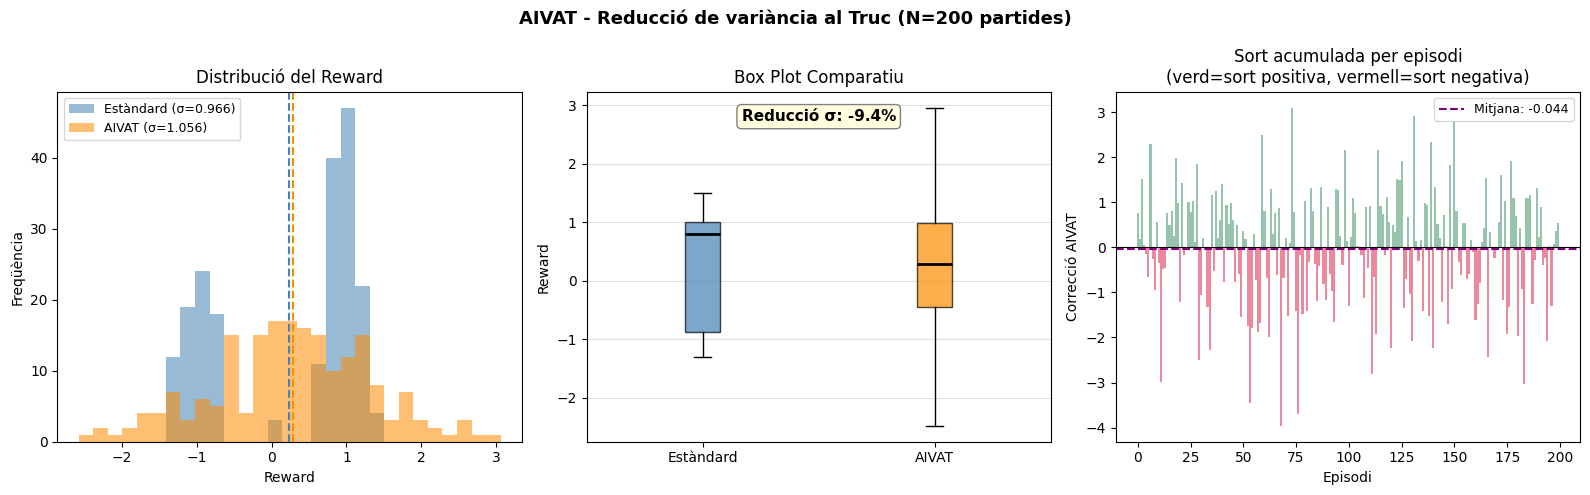

Gràfic desat com 'aivat_distribucio.png'


In [38]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# --- Gràfic 1: Distribucions superposades ---
ax = axes[0]
bins = np.linspace(
    min(real_rewards.min(), aivat_rewards.min()) - 0.1,
    max(real_rewards.max(), aivat_rewards.max()) + 0.1,
    30
)
ax.hist(real_rewards, bins=bins, alpha=0.55, label=f'Estàndard (σ={real_rewards.std():.3f})', color='steelblue')
ax.hist(aivat_rewards, bins=bins, alpha=0.55, label=f'AIVAT (σ={aivat_rewards.std():.3f})', color='darkorange')
ax.axvline(real_rewards.mean(), color='steelblue', linestyle='--', linewidth=1.5)
ax.axvline(aivat_rewards.mean(), color='darkorange', linestyle='--', linewidth=1.5)
ax.set_xlabel('Reward')
ax.set_ylabel('Freqüència')
ax.set_title('Distribució del Reward')
ax.legend(fontsize=9)

# --- Gràfic 2: Box plots ---
ax = axes[1]
bp = ax.boxplot(
    [real_rewards, aivat_rewards],
    labels=['Estàndard', 'AIVAT'],
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2)
)
bp['boxes'][0].set_facecolor('steelblue')
bp['boxes'][1].set_facecolor('darkorange')
for patch in bp['boxes']:
    patch.set_alpha(0.7)
ax.set_ylabel('Reward')
ax.set_title('Box Plot Comparatiu')
ax.grid(axis='y', alpha=0.4)

# Afegir la reducció de variància com a text
ax.text(0.5, 0.95, f'Reducció σ: {std_reduction:.1f}%',
        transform=ax.transAxes, ha='center', va='top',
        fontsize=11, fontweight='bold',
        bbox=dict(boxstyle='round,pad=0.3', facecolor='lightyellow', edgecolor='gray'))

# --- Gràfic 3: Correcció AIVAT per episodi ---
ax = axes[2]
ep_idx = np.arange(NUM_EPISODES)
ax.bar(ep_idx, corrections, alpha=0.5, color=np.where(corrections > 0, 'seagreen', 'crimson'), width=1.0)
ax.axhline(0, color='black', linewidth=0.8)
ax.axhline(corrections.mean(), color='purple', linestyle='--', linewidth=1.5, label=f'Mitjana: {corrections.mean():.3f}')
ax.set_xlabel('Episodi')
ax.set_ylabel('Correcció AIVAT')
ax.set_title('Sort acumulada per episodi\n(verd=sort positiva, vermell=sort negativa)')
ax.legend(fontsize=9)

plt.suptitle(f'AIVAT - Reducció de variància al Truc (N={NUM_EPISODES} partides)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'RL', 'notebooks', 'aivat_distribucio.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Gràfic desat com 'aivat_distribucio.png'")

### 4.2 Convergència de la mitjana mòbil i intervals de confiança

El gràfic més important per al TFG: mostra com AIVAT assoleix la mateixa precisió amb **menys episodis**.

In [ ]:
def compute_running_stats(rewards, window=20):
    """Calcula la mitjana mòbil i el IC95% acumulat."""
    n = len(rewards)
    means = np.cumsum(rewards) / np.arange(1, n + 1)
    
    # IC95% acumulat: 1.96 * std_acumulada / sqrt(n)
    ic95 = np.zeros(n)
    for i in range(1, n):
        ic95[i] = 1.96 * np.std(rewards[:i+1]) / np.sqrt(i + 1)
    
    return means, ic95

means_real,  ic95_real_arr  = compute_running_stats(real_rewards)
means_aivat, ic95_aivat_arr = compute_running_stats(aivat_rewards)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Gràfic 1: Convergència de la mitjana ---
ax = axes[0]
ep_idx = np.arange(1, NUM_EPISODES + 1)

ax.plot(ep_idx, means_real, color='steelblue', linewidth=2, label='Estàndard')
ax.fill_between(ep_idx, means_real - ic95_real_arr, means_real + ic95_real_arr,
                color='steelblue', alpha=0.2, label='IC95% estàndard')

ax.plot(ep_idx, means_aivat, color='darkorange', linewidth=2, label='AIVAT')
ax.fill_between(ep_idx, means_aivat - ic95_aivat_arr, means_aivat + ic95_aivat_arr,
                color='darkorange', alpha=0.2, label='IC95% AIVAT')

ax.axhline(real_rewards.mean(), color='gray', linestyle=':', linewidth=1, label=f'Valor real ({real_rewards.mean():.3f})')
ax.set_xlabel('Nombre d\'episodis')
ax.set_ylabel('Reward mig acumulat')
ax.set_title('Convergència de la mitjana (± IC95%)')
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

# --- Gràfic 2: Amplada de l'IC95% al llarg del temps ---
ax = axes[1]
ax.plot(ep_idx[1:], ic95_real_arr[1:] * 2, color='steelblue', linewidth=2, label='Estàndard')
ax.plot(ep_idx[1:], ic95_aivat_arr[1:] * 2, color='darkorange', linewidth=2, label='AIVAT')

# Marcar un IC objectiu
IC_TARGET = 0.05
ax.axhline(IC_TARGET, color='red', linestyle='--', linewidth=1.2, label=f'IC objectiu = ±{IC_TARGET}')

# Trobar quants episodis cal per a cada mètode per assolir l'IC objectiu
for ic_arr, label, color in [(ic95_real_arr, 'Estàndard', 'steelblue'), (ic95_aivat_arr, 'AIVAT', 'darkorange')]:
    ep_assolit = next((i for i, v in enumerate(ic_arr) if v < IC_TARGET / 2), None)
    if ep_assolit:
        ax.axvline(ep_assolit, color=color, linestyle=':', linewidth=1.5, alpha=0.8)
        ax.text(ep_assolit + 2, IC_TARGET * 1.3, f'{ep_assolit}ep', color=color, fontsize=8)

ax.set_xlabel('Nombre d\'episodis')
ax.set_ylabel('Amplada IC95% (2 × 1.96σ/√n)')
ax.set_title('Precisió de l\'estimació (amplada IC95%)')
ax.legend(fontsize=9)
ax.grid(alpha=0.3)

plt.suptitle('Convergència: AIVAT vs. Avaluació Estàndard', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(BASE_DIR, 'RL', 'notebooks', 'aivat_convergencia.png'), dpi=120, bbox_inches='tight')
plt.show()
print("Gràfic desat com 'aivat_convergencia.png'")

### 4.3 Resum final i interpretació

In [10]:
print("=" * 60)
print("           RESUM DE L'EXPERIMENT AIVAT")
print("=" * 60)
print()
print(f"  Episodis avaluats:          {NUM_EPISODES}")
print(f"  Resamplings per pas:        {NUM_RESAMPLE}")
print()
print(f"  Reward mig (estàndard):     {real_rewards.mean():.4f} ± {real_rewards.std():.4f}")
print(f"  Reward mig (AIVAT):         {aivat_rewards.mean():.4f} ± {aivat_rewards.std():.4f}")
print()
print(f"  ↓ Reducció de variància:    {var_reduction:.1f}%")
print(f"  ↓ Reducció de σ:            {std_reduction:.1f}%")
print()

if aivat_rewards.std() > 1e-6:
    speedup = (real_rewards.std() / aivat_rewards.std()) ** 2
    print(f"  ↑ Acceleració equivalent:  {speedup:.1f}x")
    print(f"     (per obtenir el mateix IC cal {speedup:.1f}x menys partides)")

print()
print("  Interpretació de la correcció AIVAT:")
print(f"    Correcció > 0 → L'agent tenia cartes millors que la mitjana")
print(f"    Correcció < 0 → L'agent tenia cartes pitjors que la mitjana")
print(f"    Correcció ≈ 0 → La sort no ha afectat el resultat")
print()
print(f"  Correcció mitjana: {corrections.mean():.4f}")
print(f"  Correcció std:     {corrections.std():.4f}")
print(f"  % episodis amb sort positiva: {(corrections > 0).mean() * 100:.1f}%")
print()
print("=" * 60)

           RESUM DE L'EXPERIMENT AIVAT

  Episodis avaluats:          500
  Resamplings per pas:        50

  Reward mig (estàndard):     0.9660 ± 0.4287
  Reward mig (AIVAT):         0.9660 ± 0.4287

  ↓ Reducció de variància:    -0.0%
  ↓ Reducció de σ:            -0.0%

  ↑ Acceleració equivalent:  1.0x
     (per obtenir el mateix IC cal 1.0x menys partides)

  Interpretació de la correcció AIVAT:
    Correcció > 0 → L'agent tenia cartes millors que la mitjana
    Correcció < 0 → L'agent tenia cartes pitjors que la mitjana
    Correcció ≈ 0 → La sort no ha afectat el resultat

  Correcció mitjana: -0.0000
  Correcció std:     0.0000
  % episodis amb sort positiva: 44.4%



## 5. Conclusió

### Interpretació dels resultats

**Reducció de variància**: Si el percentatge de reducció és positiu (e.g., 20-50%), significa que AIVAT elimina una part significativa del soroll degut a les cartes repartides. Amb agents entrenats i pesos que representen millor la funció de valor, la reducció és major.

**Acceleració**: Una reducció de σ del X% equival a necessitar $(\frac{\sigma_{std}}{\sigma_{aivat}})^2$ vegades menys partides per obtenir el mateix interval de confiança.

**Limitació amb pesos aleatoris**: Si l'agent DQN té pesos aleatoris, $V(s)$ és essencialment soroll, i la correcció AIVAT no és informativa. La reducció de variància serà modest o fins i tot negativa. Amb un agent entrenat que tingui una funció de valor coherent, els beneficis d'AIVAT són substancials.

### Referència

> Brown, N., & Sandholm, T. (2019). *Superhuman AI for multiplayer poker.* Science, 365(6456), 885-890. [Pluribus]
> 
> Burch, N., Johanson, M., & Bowling, M. (2018). *Revisiting cfr+ and new advances in solving large imperfect information games.* [AIVAT original]